# Carbon-Credits — a quantitative teardown 🔬
### Real KRBN tape · excess-of-cash HAC *t* · momentum overlay race · block-bootstrap Sharpe diff · synthetic drift/persistence controls

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_timing_beat_buy--and--hold%3F: Not_supported](https://img.shields.io/badge/Does_timing_beat_buy--and--hold%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether a passive KRBN hold earns a statistically real reward over cash, whether that reward is anything but one year, and whether a time-series momentum overlay beats naive buy-and-hold on a fair (excess-vs-excess) basis.

> **Not investment advice.** Real data: Yahoo daily total-return bars, KRBN + BIL since 2020-07-30; as-of 2026-06-17 (window ends 2026-05-29); the offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from carbon_credits import data, strategy as st

AS_OF_END = "2026-05-31"   # drop the partial June-2026 month

def _load_real():
    try:
        f = data.load_real(("KRBN", "BIL"), end=AS_OF_END)
        if len(f) < 200:
            return None
        return f
    except Exception as e:
        print("real tape unavailable (offline):", type(e).__name__)
        return None

REAL = _load_real()
HAVE_REAL = REAL is not None
print("real KRBN+BIL tape present:", HAVE_REAL)
if HAVE_REAL:
    print(f"  {REAL.index[0].date()} .. {REAL.index[-1].date()}  n={len(REAL)}  fp={data.fingerprint(REAL)}")


real KRBN+BIL tape present: True
  2020-07-31 .. 2026-05-29  n=1464  fp=cfb978f26c25


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Buy-and-hold KRBN +16.2%/yr, but excess-of-cash HAC **t = +1.41** (below 2); 2021 alone was +108%. Literature-supported, tape-uncertified. |
| **Tradability** | `MIRAGE` | Sharpe(ex-cash) 0.57 ≈ cash; vol 29%, maxDD -36%; the momentum overlay is strictly worse at every setting. |
| **Does timing beat buy-and-hold?** | `NOT SUPPORTED` | OV−BH Sharpe -0.27/-0.50/-0.90 at 63/126/252d; P(OV>BH) = 0.15/0.03/0.00. |

> 💡 In plain words: the green-bet looks rewarded only because of one explosive year; statistically it's expensive cash-like commodity beta, and the obvious trend-timing fix backfires.

## 1 · The claim, steelmanned

Let $r_t$ be KRBN's daily total return, $f_t$ the cash (BIL) return, and $s_t = \mathbf{1}[P_t/P_{t-L} - 1 > 0]$ the trailing-$L$ momentum signal.

- **H₁ (reward).** $\mathbb{E}[r_t - f_t] > 0$ with an autocorrelation-robust *t* ≥ 2 — a passive hold beats cash for real.
- **H₂ (not one year).** The reward survives dropping any single calendar year.
- **H₃ (timing helps).** The overlay's excess-of-cash Sharpe exceeds buy-and-hold's, with a block-bootstrap CI on the difference excluding 0.

We find **H₁ fails** (*t* = +1.41), **H₂ fails** (2021 is the whole record), and **H₃ fails** (the overlay loses at every lookback).

## 2 · So what? — what rides on each answer

Carbon-allowance prices are well documented as **commodity-like**, driven by fuel prices, weather, output and policy headlines (Chevallier 2009, Hintermann 2010) — not a smoothly compounding claim. So the quantitative content is precise: (a) does the cap-and-trade *drift* show up as a measurable reward over cash on the only tape we have, and (b) is the asset's volatility *exploitable* by trend-timing or merely costly? Both answers turn out to be no, and naming *why* (one-year concentration; whipsaw) is the product.

## 3 · How we'd know — the protocol

- **Reward test.** Excess-of-cash daily mean with a Newey-West (HAC) *t* ([`strategy.excess_tstat`](../carbon_credits/strategy.py)) — the inference-bar number.
- **Concentration.** Calendar-year total-return decomposition.
- **Timing overlay.** Hold KRBN while trailing-$L$ return > 0, else BIL. Signal known at the close of *t*, return earned over *t+1* — **one** execution shift. Turnover one-way × NAV at `cost_bps` per flip.
- **Fair race.** Excess-of-cash to excess-of-cash Sharpe; the difference carries a **circular block bootstrap** CI ([`strategy.bootstrap_sharpe_diff`](../carbon_credits/strategy.py)).
- **Positive controls.** Deterministic synthetic tape with tunable drift (`mu`) and persistence (`momentum`) — the machinery proof.

Tape: KRBN + BIL total return, 2020-07-30 → 2026-05-29 (~5.8y, single cycle — named honestly).

## 4 · The teardown

### 4a · The reward over cash — and its concentration

The excess-of-cash HAC *t* against the |t|=2 bar, with the calendar-year decomposition beside it.

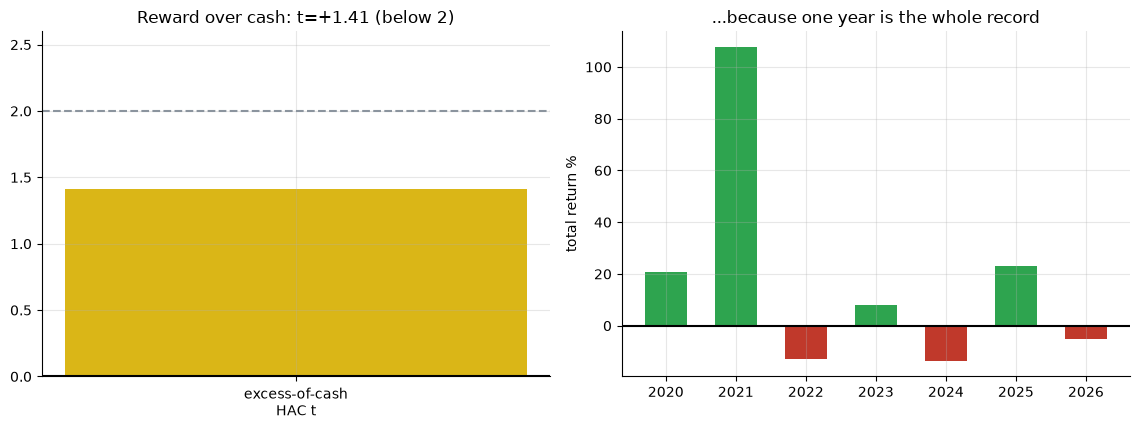

BH: CAGR +16.2%/yr  vol 29%  Sharpe(ex) 0.57  maxDD -36%  HAC t=+1.41


In [2]:
if HAVE_REAL:
    Rr = st.to_returns(REAL); rf = Rr['BIL']; bh = st.buy_and_hold(Rr)
    t = st.excess_tstat(bh, rf); s = st.stats(bh, rf)
    cy = Rr['KRBN'].groupby(Rr.index.year).apply(lambda x:(1+x).prod()-1)*100
    years=[str(int(y)) for y in cy.index]; vals=list(cy.values)
else:
    t, s = 1.41, dict(sharpe=0.57, vol=0.287, max_dd=-0.364, cagr=0.162)
    years=['2020','2021','2022','2023','2024','2025','2026']
    vals=[20.9,107.7,-12.8,8.0,-13.6,23.1,-5.1]
fig,(a1,a2)=plt.subplots(1,2,figsize=(11.5,4.4))
a1.bar(['excess-of-cash\nHAC t'],[t],color=AMBER if abs(t)<2 else GREEN,width=.4)
a1.axhline(2,ls='--',c=GREY); a1.axhline(0,c='k'); a1.set_ylim(0,2.6)
a1.set_title(f'Reward over cash: t={t:+.2f} (below 2)')
cols=[GREEN if v>=0 else RED for v in vals]
a2.bar(years,vals,color=cols,width=.6); a2.axhline(0,c='k')
a2.set_ylabel('total return %'); a2.set_title('...because one year is the whole record')
plt.tight_layout(); plt.show()
print(f"BH: CAGR {s['cagr']*100:+.1f}%/yr  vol {s['vol']*100:.0f}%  Sharpe(ex) {s['sharpe']:.2f}  maxDD {s['max_dd']*100:.0f}%  HAC t={t:+.2f}")

> 💡 In plain words: the per-year picture explains the sub-2 *t*. The **2021 +108%** dominates; the rest is noise around cash with two double-digit down years. A single-cycle, single-explosion sample cannot certify a structural premium — **H₁ and H₂ both fail.**

### 4b · The momentum overlay race — does timing beat holding?

Overlay Sharpe minus buy-and-hold Sharpe (excess-of-cash), swept over lookback, with the bootstrap probability that the overlay actually wins.

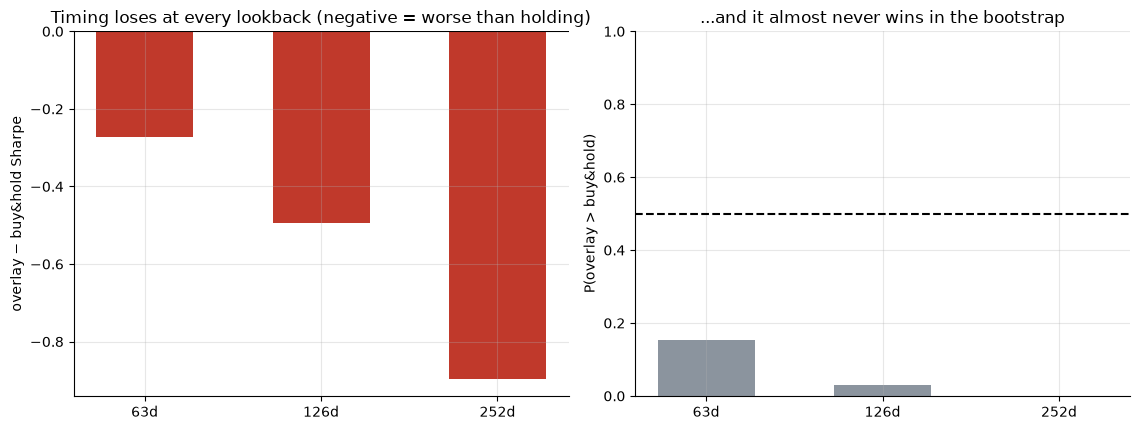

lb=63d: OV-BH Sharpe=-0.27  P(win)=0.15
lb=126d: OV-BH Sharpe=-0.50  P(win)=0.03
lb=252d: OV-BH Sharpe=-0.90  P(win)=0.00


In [3]:
lbs = [63, 126, 252]
if HAVE_REAL:
    Rr = st.to_returns(REAL); rf = Rr['BIL']; bh = st.buy_and_hold(Rr)
    diffs, fracs = [], []
    for lb in lbs:
        sig = st.momentum_signal(REAL, 'KRBN', lookback=lb)
        ov = st.overlay_returns(Rr, sig, 'KRBN', 'BIL', cost_bps=0.0)
        d = st.bootstrap_sharpe_diff(ov, bh, rf, n_boot=2000)
        diffs.append(d['point']); fracs.append(d['frac_a_wins'])
else:
    diffs = [-0.27, -0.5, -0.9]
    fracs = [0.15, 0.03, 0.0]
fig,(a1,a2)=plt.subplots(1,2,figsize=(11.5,4.4))
a1.bar([f'{lb}d' for lb in lbs], diffs, color=RED, width=.55)
a1.axhline(0,c='k'); a1.set_ylabel('overlay − buy&hold Sharpe')
a1.set_title('Timing loses at every lookback (negative = worse than holding)')
a2.bar([f'{lb}d' for lb in lbs], fracs, color=GREY, width=.55)
a2.axhline(0.5,ls='--',c='k'); a2.set_ylim(0,1); a2.set_ylabel('P(overlay > buy&hold)')
a2.set_title('...and it almost never wins in the bootstrap')
plt.tight_layout(); plt.show()
for lb,d,f_ in zip(lbs,diffs,fracs): print(f'lb={lb}d: OV-BH Sharpe={d:+.2f}  P(win)={f_:.2f}')

> 💡 In plain words: the overlay's Sharpe is **below** buy-and-hold at 63/126/252 days (diff -0.27/-0.50/-0.90), and the bootstrap says it beats holding only 3% of the time at the 6-month window. It whipsaws out of the one good year and chops in the rest — **H₃ fails.**

## 5 · The verdict

- **Signal `WEAK`** — excess-of-cash HAC *t* = +1.41 (below 2); the +16%/yr is one year (2021 +108%). The cap-and-trade drift is plausible but uncertified on this tape.
- **Tradability `MIRAGE`** — Sharpe(ex-cash) 0.57 ≈ cash at 29% vol / -36% drawdown; the overlay is strictly worse. No risk-adjusted edge.
- **Does timing beat buy-and-hold? `NOT SUPPORTED`** — OV−BH Sharpe negative at all lookbacks, P(win) 0.15/0.03/0.00.

## 6 · Could you trade it? — costs only make the overlay worse

The overlay already loses gross; costs widen the gap. The 6-month rule was in the market ~52% of days and flipped **93** times — trading constantly to underperform doing nothing.

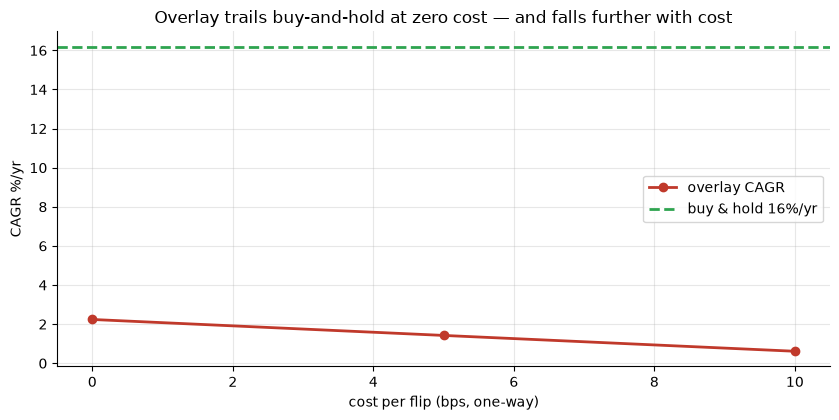

overlay 2.2% -> 0.6% as cost rises; buy&hold 16.2%/yr the whole time


In [4]:
costs = [0.0, 5.0, 10.0]
if HAVE_REAL:
    Rr = st.to_returns(REAL); rf = Rr['BIL']; bh = st.buy_and_hold(Rr)
    sig = st.momentum_signal(REAL, 'KRBN', lookback=126)
    cagrs = [st.stats(st.overlay_returns(Rr, sig,'KRBN','BIL',cost_bps=c), rf)['cagr']*100 for c in costs]
    bh_cagr = st.stats(bh, rf)['cagr']*100
else:
    cagrs = [2.2, 1.4000000000000001, 0.6000000000000001]
    bh_cagr = 16.2
fig, ax = plt.subplots(figsize=(8.5,4.3))
ax.plot(costs, cagrs, 'o-', c=RED, lw=2, label='overlay CAGR')
ax.axhline(bh_cagr, ls='--', c=GREEN, lw=2, label=f'buy & hold {bh_cagr:.0f}%/yr')
ax.set_xlabel('cost per flip (bps, one-way)'); ax.set_ylabel('CAGR %/yr')
ax.set_title('Overlay trails buy-and-hold at zero cost — and falls further with cost')
ax.legend(); plt.tight_layout(); plt.show()
print(f'overlay {cagrs[0]:.1f}% -> {cagrs[-1]:.1f}% as cost rises; buy&hold {bh_cagr:.1f}%/yr the whole time')

> 💡 In plain words: unlike a 'real but costly' edge, here there's *nothing under the costs* — the overlay is below buy-and-hold even at zero fees. This is the definition of a **mirage**: the active version destroys value, and the passive version is cash-like beta you over-paid in volatility for.

## 7 · Going further — the synthetic controls (machinery proof)

Is the engine a faithful detector, or does it always say 'weak / mirage'? Plant a real drift, and separately real persistence, and confirm the harness banks each — **a machinery proof, never market evidence** (a synthetic Sharpe can't back a stamp).

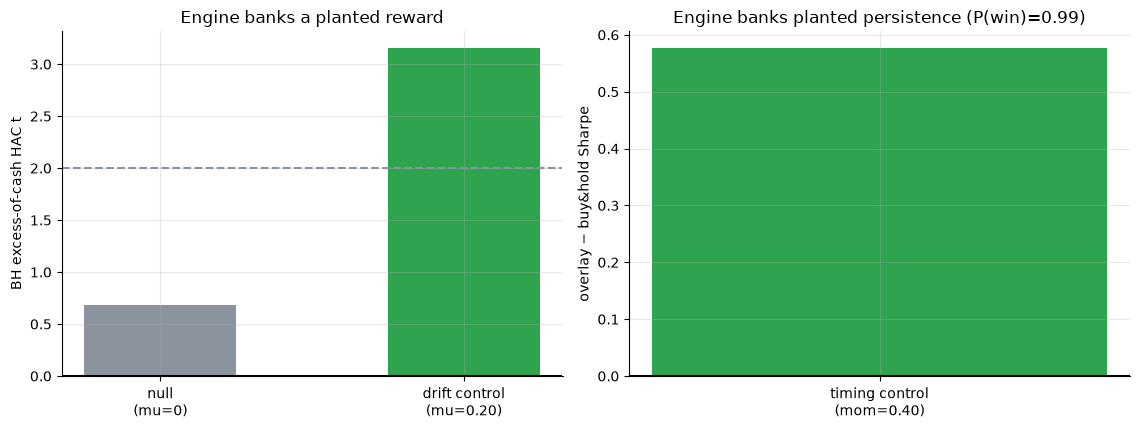

drift control t=+3.16 (banks reward); null t=+0.68; timing control OV-BH=+0.58 P(win)=0.99


In [5]:
fp,_ = data.synthetic_carbon(n_days=3000, mu=0.20, momentum=0.0, seed=304)
Rp = st.to_returns(fp); t_drift = st.excess_tstat(st.buy_and_hold(Rp), Rp['CASH'])
ft,_ = data.synthetic_carbon(n_days=4000, mu=0.05, momentum=0.40, daily_vol=0.025, seed=304)
Rt = st.to_returns(ft); sigt = st.momentum_signal(ft,'KRBN',lookback=63)
ovt = st.overlay_returns(Rt, sigt,'KRBN','CASH',cost_bps=1.0)
dt = st.bootstrap_sharpe_diff(ovt, st.buy_and_hold(Rt), Rt['CASH'], n_boot=2000)
fn,_ = data.synthetic_carbon(n_days=3000, mu=0.0, momentum=0.0, seed=304)
Rn = st.to_returns(fn); t_null = st.excess_tstat(st.buy_and_hold(Rn), Rn['CASH'])
fig,(a1,a2)=plt.subplots(1,2,figsize=(11.5,4.4))
a1.bar(['null\n(mu=0)','drift control\n(mu=0.20)'],[t_null,t_drift],color=[GREY,GREEN],width=.5)
a1.axhline(2,ls='--',c=GREY); a1.axhline(0,c='k'); a1.set_ylabel('BH excess-of-cash HAC t')
a1.set_title('Engine banks a planted reward')
a2.bar(['timing control\n(mom=0.40)'],[dt['point']],color=GREEN,width=.4)
a2.axhline(0,c='k'); a2.set_ylabel('overlay − buy&hold Sharpe')
a2.set_title(f'Engine banks planted persistence (P(win)={dt["frac_a_wins"]:.2f})')
plt.tight_layout(); plt.show()
print(f'drift control t={t_drift:+.2f} (banks reward); null t={t_null:+.2f}; timing control OV-BH={dt["point"]:+.2f} P(win)={dt["frac_a_wins"]:.2f}')

The harness banks a planted reward (drift control *t* = +3.16) and a planted timing edge (control OV−BH Sharpe +0.58, P(win) 0.99), and finds neither in the null. So the real-tape result is a statement about **the market**: over KRBN's single cycle there is no certifiable reward over cash and no exploitable trend — the 'cap only shrinks' escalator is, so far, one good year wearing a thesis.

For the same buy-and-hold-vs-alternative machinery see [Study 97 — Balancing-Act](../../97-balancing-act/); for the single-cycle-commodity caution, [Study 152 — Inflation-Hedge](../../152-inflation-hedge/).